# 202235203 고수호
# **3week - wine.csv 데이터에 대한 Regression**


# **# 데이터 세트 불러오기**
`import pandas as pd` : 데이터를 표(Table) 형태로 다루기 위한 **Pandas** 라이브러리.  
`import numpy as np` : 수치 계산 및 행렬 연산을 위한 **NumPy** 라이브러리.  
`import matplotlib.pyplot as plt` : 데이터를 그래프로 시각화하기 위한 **Matplotlib** 라이브러리.  
`path = '/content/drive/MyDrive/Colab Notebooks/3week/wine.csv'` : 데이터 파일이 저장된 경로를 문자열 변수 '**path**'에 저장.  
`df2 = pd.read_csv(path)` : 읽어온 데이터는 데이터프레임 형태로 변수 '**df2**'에 저장.  



In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/Colab Notebooks/3week/wine.csv'

df2 = pd.read_csv(path)

df2

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


# **# 데이터 전처리(y)**
`y = df2['Alcohol']` : 예측하고자 하는 목표 변수(알코올)를 변수 '**y**'에 저장.  
`y.value_counts()` : 알코올 클래스별 데이터 개수를 확인.

In [18]:
y = df2['Alcohol']
y.value_counts()

,count
Alcohol,
13.05,6
12.37,6
12.08,5
12.29,4
12.00,3
...,...
12.82,1
12.20,1
14.16,1


# **# 데이터 전처리(X)**
`X = df2.drop('Alcohol', axis=1)` : 전체 데이터에서 '**Alcohol**' 열을 제외한 나머지 특징들을 변수 '**X**'에 저장.  
`X.head()` : 분리된 특징 데이터의 상위 5개 행을 확인.

In [19]:
X=df2.drop('Alcohol',axis=1)
X.head()

,Wine,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


# **# 데이터셋 분리 (Training & Test Set)**
`from sklearn.model_selection import train_test_split` : 데이터를 나누기 위한 사이킷런의 함수.  
`test_size=0.25` : 전체 데이터의 **25%** 를 평가용(Test)으로, **75%** 를 학습용(Train)으로 설정.  
`random_state=0` : 실행할 때마다 동일한 결과가 나오도록 난수 시드 고정.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

# **# 모델별 학습 및 평가 1 - 선형 회귀 알고리즘 (Linear Regression)**
`from sklearn.linear_model import LinearRegression` : **선형 회귀 알고리즘**을 사용하기 위한 라이브러리 임포트.  
`model.fit(X_train, y_train)` : 학습 데이터를 사용하여 선형 회귀 모델을 학습.  
`ly_preds = model.predict(X_test)` : 테스트 데이터에 대한 예측값을 생성.  

### **평균 제곱 오차(Mean Squared Error, MSE) 계산법**
**예측값과 실제값의 차이(오차)를 제곱하여 평균을 낸 값**으로, 0에 가까울수록 모델의 성능이 좋음.

1. `mean_squared_error(ly_preds, y_test)` : **Scikit-learn**에서 제공하는 함수를 사용하여 간편하게 MSE 계산.  
2. `mse_np(actual, predicted)` : **NumPy**의 배열 연산(**np.mean**)을 활용하여 수식을 직접 구현.  
3. `mse(actual, predicted)` : 라이브러리 없이 **순수 파이썬**의 반복문(**sum, zip**)을 사용하여 수식의 원리대로 구현.


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

평균제곱근오차 0.3511470189437248
평균제곱근오차 0.3511470189437248
평균제곱근오차 0.3511470189437248


# **# 시각화를 통한 모델 성능 확인 1 - 선형 회귀 알고리즘 (Linear Regression)**
`plt.figure(figsize=(10,5))` : 그래프의 가로 길이를 10, 세로 길이를 5로 설정하여 크기를 조절.  
`plt.scatter(..., label='y_test')` : 테스트 데이터의 'Phenols' 수치에 따른 **알코올 값**을 산점도로 표시.  
`plt.scatter(..., c='y', label='ly_preds')` : 동일한 기준에 대해 **모델이 예측한 값**을 노란색(**c='y'**)으로 겹쳐서 표시.  
`plt.show()` : 생성된 그래프를 화면에 출력.

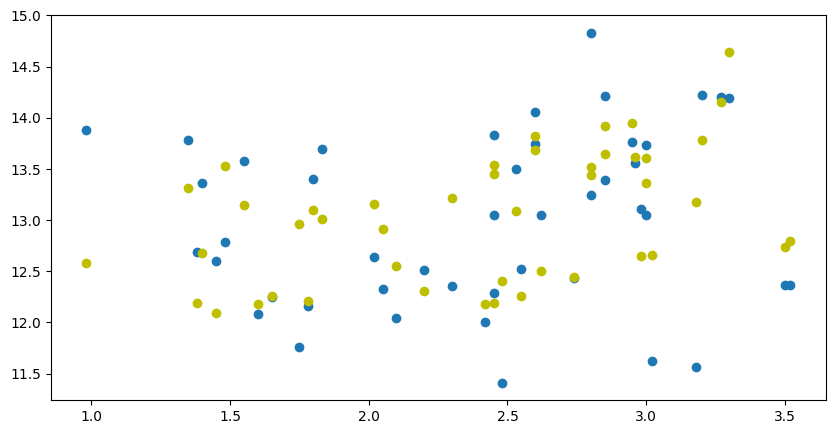

In [22]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Phenols'], y_test, label='y_test')
plt.scatter(X_test['Phenols'], ly_preds, c='y', label='ly_preds')
plt.show()


# **# 모델별 학습 및 평가 2 - 결정 트리 알고리즘 (Decision Tree)**
`from sklearn.tree import DecisionTreeRegressor` : **결정 트리 방식**의 회귀 모델을 사용하기 위한 라이브러리 임포트.  
`model.fit(X_train, y_train)` : 학습 데이터를 사용하여 결정 트리 모델을 학습.  
`dy_preds = model.predict(X_test)` : 테스트 데이터에 대한 예측값 생성.  
`mean_squared_error(dy_preds, y_test)` : 실제 값과 예측 값의 차이를 제곱하여 평균을 낸 오차값 출력.

In [23]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test)
print('평균제곱근오차', mean_squared_error(dy_preds, y_test))

평균제곱근오차 0.6826066666666666


# **# 시각화를 통한 모델 성능 확인 2 - 결정 트리 알고리즘 (Decision Tree)**
`plt.figure(figsize=(10,5))` : 그래프의 가로 길이를 10, 세로 길이를 5로 설정하여 크기를 조절.  
`plt.scatter(..., label='y_test')` : 테스트 데이터의 'Phenols' 수치에 따른 **알코올 값**을 산점도로 표시.  
`plt.scatter(..., c='y', label='dy_preds')` : 동일한 기준에 대해 **모델이 예측한 값**을 노란색(**c='y'**)으로 겹쳐서 표시.   
`plt.show()` : 생성된 그래프를 화면에 출력.

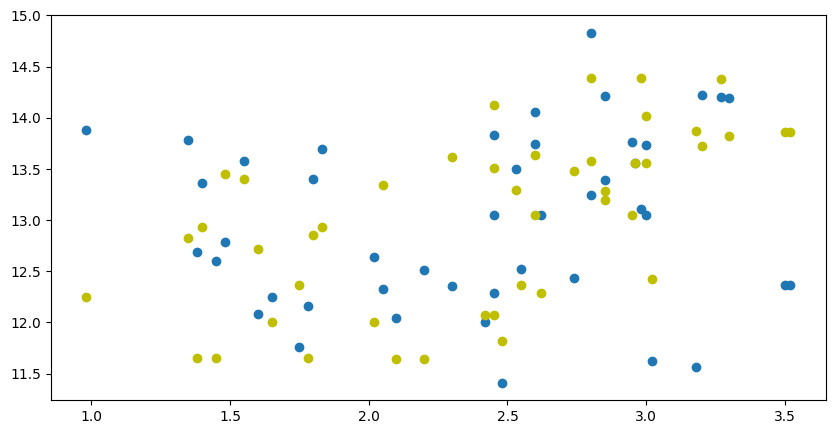

In [24]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Phenols'], y_test, label='y_test')
plt.scatter(X_test['Phenols'], dy_preds, c='y', label='dy_preds')
plt.show()

# **# 모델별 학습 및 평가 3 - 랜덤 포레스트 알고리즘 (Random Forest)**
`from sklearn.ensemble import RandomForestRegressor` : **랜덤 포레스트 회귀 모델**을 사용하기 위한 라이브러리 임포트.  
`model = RandomForestRegressor()` : 여러 개의 결정 트리를 사용하는 랜덤 포레스트 회귀 객체 생성.  
`model.fit(X_train, y_train)` : 학습 데이터를 사용하여 숲(**Forest**)을 구성하고 모델을 학습.  
`ry_preds = model.predict(X_test)` : 테스트 데이터를 넣어 각 트리의 예측치를 종합한 최종 예측값(**ry_preds**) 생성.  
`mean_squared_error(ry_preds, y_test)` : 실제 값과 예측 값의 차이를 제곱하여 평균을 낸 오차값 출력.

In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test)
print('평균제곱근오차', mean_squared_error(ry_preds, y_test))

평균제곱근오차 0.45145275622222053


# **# 시각화를 통한 모델 성능 확인 3 - 랜덤 포레스트 알고리즘 (Random Forest)**
`plt.figure(figsize=(10,5))` : 그래프의 가로 길이를 10, 세로 길이를 5로 설정하여 크기를 조절.  
`plt.scatter(..., label='y_test')` : 테스트 데이터의 'Phenols' 수치에 따른 **알코올 값**을 산점도로 표시.  
`plt.scatter(..., c='y', label='ry_preds')` : 동일한 기준에 대해 **모델이 예측한 값**을 노란색(**c='y'**)으로 겹쳐서 표시.   
`plt.show()` : 생성된 그래프를 화면에 출력.

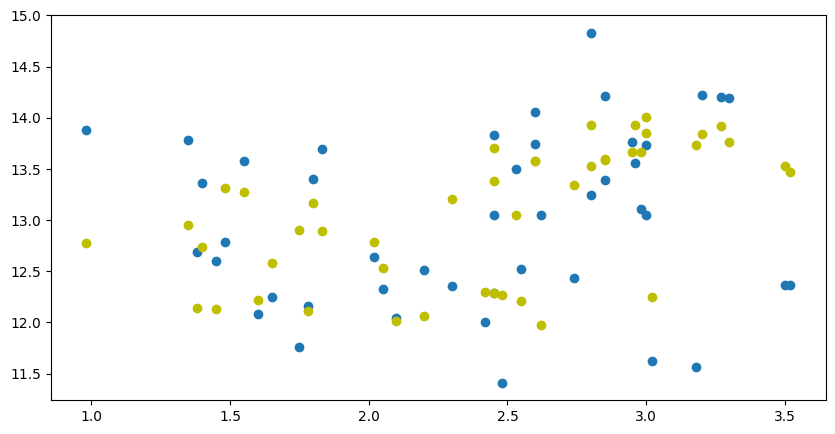

In [26]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Phenols'], y_test, label='y_test')
plt.scatter(X_test['Phenols'], ry_preds, c='y', label='ry_preds')
plt.show()

# **# 모델별 학습 및 평가 4 - kNN 알고리즘 (k-Nearest Neighbor)**
`from sklearn.neighbors import KNeighborsRegressor` : 주변의 가장 가까운 데이터를 참고하여 분류하는 kNN 라이브러리 임포트.  
`knn = KNeighborsRegressor(n_neighbors=6)` : 분류 시 참고할 이웃의 수를 **6개**로 설정한 모델 객체 생성.  
`knn.fit(X_train, y_train)` : 학습 데이터를 바탕으로 이웃들의 위치 관계를 학습.  
`y_pred = knn.predict(X_test)` : 테스트 데이터에 대한 예측값 생성.  
`mean_squared_error(y_pred, y_test)` : 실제 값과 예측 값의 차이를 제곱하여 평균을 낸 오차값 출력.

In [27]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=6)
knn.fit(X_train, y_train)

from sklearn import metrics

y_pred = knn.predict(X_test)
print('평균제곱근오차', mean_squared_error(y_pred, y_test))

평균제곱근오차 0.37304895061728444


# **# 시각화를 통한 모델 성능 확인 4 - kNN 알고리즘 (k-Nearest Neighbor)**
`plt.figure(figsize=(10,5))` : 그래프의 가로 길이를 10, 세로 길이를 5로 설정하여 크기를 조절.  
`plt.scatter(..., label='y_test')` : 테스트 데이터의 'Phenols' 수치에 따른 **알코올 값**을 산점도로 표시.  
`plt.scatter(..., c='y', label='y_pred')` : 동일한 기준에 대해 **모델이 예측한 값**을 노란색(**c='y'**)으로 겹쳐서 표시.   
`plt.show()` : 생성된 그래프를 화면에 출력.

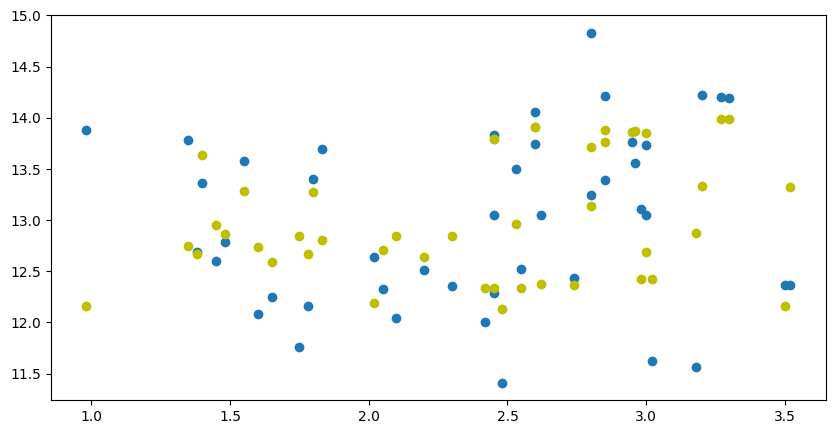

In [28]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Phenols'], y_test, label='y_test')
plt.scatter(X_test['Phenols'], y_pred, c='y', label='y_pred')
plt.show()